In [ ]:
from src.data_preprocessing import *
import numpy as np
import matplotlib.pyplot as plt
import io
import torch
from torch.utils.data import DataLoader

%load_ext autoreload
%autoreload 2

cpu
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


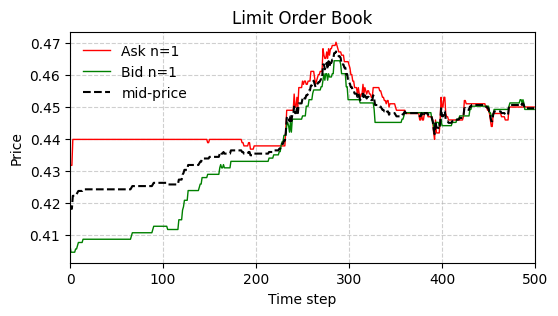

In [ ]:
pliki = get_txt_paths()
raw_text = read_zip_file(pliki[0])

data = np.genfromtxt(io.StringIO(raw_text)).T 

#######################################################
# INDEKSOWANIE W ZBIORZE
# (n przechodzi od 0 do 9)
# n=0 to poziom 1 (najlepsze oferty), n=9 to poziom 10.
#######################################################
'''
1. surowe dane
data[:, 4*n + 0] -> Cena Ask (oferta sprzedaży)
data[:, 4*n + 1] -> Wolumen Ask
data[:, 4*n + 2] -> Cena Bid (oferta kupna)
data[:, 4*n + 3] -> Wolumen Bid

2. spread/mid-price
data[:, 2*n + 40] -> Spread (Ask-Bid)
data[:, 2*n + 41] -> Mid-Price (Ask+Bid)/2

3. randomowe cechy
data[:, 60:84]

4. cechy historyczne/dynamika
a) surowe dane
data[:, 4*n + 84] -> Delta wstecz Ceny Ask
data[:, 4*n + 85] -> Delta wstecz Wolumenu Ask
data[:, 4*n + 86] -> Delta wstecz Ceny Bid
data[:, 4*n + 87] -> Delta wstecz Wolumenu Bid

b) spread/mid-price
  data[:, 2*n + 124] -> Delta wstecz Spreadu
  data[:, 2*n + 125] -> Delta wstecz Mid-Price'u

5. przewidywanie
Przewidywany kierunek ceny: 1 (wzrost), 2 (bez zmian), 3 (spadek).
  data[:, 144] -> 10 kroków w przód
  data[:, 145] -> 20 kroków w przód
  data[:, 146] -> 30 kroków w przód
  data[:, 147] -> 50 kroków w przód
  data[:, 148] -> 100 kroków w przód
'''

n = 500
dane_wycinek = data[:n, :]

czas = range(n)

ask_price = data[:n, 0]
bid_price = data[:n, 2]

# uzywam tego, bo ten z datasetu jest dziwnie znormalizowany
mid_price_calc = (ask_price + bid_price)/2.0

plt.figure(figsize=(6, 3))
plt.plot(czas, ask_price, label='Ask n=1', color='red', linewidth=1)
plt.plot(czas, bid_price, label='Bid n=1', color='green', linewidth=1)
plt.plot(czas, mid_price_calc, '--', label='mid-price', color='k', linewidth=1.5)

plt.title("Limit Order Book")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend(frameon=False)
plt.xlim(0, n)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
wszystkie_pliki = get_txt_paths()
pliki_do_testu = wszystkie_pliki[:3] 

nazwa_bazy = "test.h5"
build_hdf5_database(pliki_do_testu, nazwa_bazy)

Teraz: 1/3: BenchmarkDatasets/Auction/1.Auction_Zscore/Auction_Zscore_Testing/Test_Dst_Auction_ZScore_CF_1.txt
Teraz: 2/3: BenchmarkDatasets/Auction/1.Auction_Zscore/Auction_Zscore_Testing/Test_Dst_Auction_ZScore_CF_2.txt
Teraz: 3/3: BenchmarkDatasets/Auction/1.Auction_Zscore/Auction_Zscore_Testing/Test_Dst_Auction_ZScore_CF_3.txt


In [17]:
wybrane_cechy = [0, 1, 2, 3]

dataset = LOBDataset(file_path="test.h5", 
                     sequence_length=7, 
                     horizon_idx=0, 
                     features_idx=wybrane_cechy)

train_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

X_batch, Y_batch = next(iter(train_loader))

print("shape X_batch:", X_batch.shape)
print("shape Y_batch:", Y_batch.shape)



cpu
shape X_batch: torch.Size([64, 7, 4])
shape Y_batch: torch.Size([64])
